# Federated Fine-Tuning of Gemma-2B with LoRA (4-bit) — IID Data Split across 3 Organizations

This notebook simulates the federated learning pipeline described below, entirely on a single machine (one Jupyter kernel simulating 3 clients + 1 server):

```
[Org A: MedQuAD shard 1]  [Org B: MedQuAD shard 2]  [Org C: MedQuAD shard 3]
        |                         |                          |
   Local fine-tune           Local fine-tune            Local fine-tune
        |                         |                          |
        +-----------> Aggregator (FedAvg) <-----------------+
                            |
                     Global Model v1
                            |
              (Optional centralized fine-tune)
                            |
                     Global Model v1.5
                            |
              Distributed back to orgs --> repeat rounds
                            |
                     Global Model v2
                            |
        Each org locally fine-tunes their own copy for
        personalization (Global + Local = Personalized Model)
```

**Key difference from the multi-dataset version:**
Instead of using 3 different domain datasets (food, healthcare, python), this notebook downloads a **single dataset** (`pythonafroz/medquad-medical-question-answer-for-ai-research`) and splits it into **3 equal IID (Independent and Identically Distributed) partitions**. Each org receives a disjoint, randomly-shuffled shard of the same dataset, so all clients see the same data distribution — the standard IID federated learning baseline.

**Stack**
- **Base model:** `google/gemma-2b` (4-bit quantized via `bitsandbytes`)
- **Fine-tuning:** LoRA, rank = 3, via `peft`
- **Federated logic:** manual FedAvg over LoRA adapter weights (no external FL server needed)
- **Data:** Single Kaggle dataset `pythonafroz/medquad-medical-question-answer-for-ai-research` split into 3 equal IID shards

**What this notebook does, step by step**
1. Install/import libraries
2. Authenticate Kaggle + Hugging Face, load 4-bit Gemma-2B + LoRA(r=3)
3. Download & preprocess the single dataset, then split into 3 IID shards (one per org)
4. Define a `Client` class (local training) and FedAvg aggregation over LoRA weights only
5. Run federated rounds -> Global Model v1
6. (Optional) centralized fine-tune of the global model -> Global Model v1.5
7. Repeat federated rounds -> Global Model v2
8. Each org personalizes: Global v2 + local LoRA fine-tune = Personalized Model
9. Quick qualitative evaluation per org

> **Hardware note:** Gemma-2B in 4-bit + LoRA(r=3) fits comfortably on a single 16GB GPU (e.g. Colab T4/L4, Kaggle P100/T4). CPU-only will work but will be very slow.


## 1. Install dependencies

In [1]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets kagglehub trl sentencepiece scikit-learn
!pip install -q -U flwr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/974.5 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/264.7 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 4.5/4.5 MB 160.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/6.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━ 5.2/6.9 MB 152.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 6.9/6.9 MB 151.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/66.5 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [2]:
import os, json, copy, random, gc, time
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    get_peft_model_state_dict,
    set_peft_model_state_dict,
    PeftModel,
    prepare_model_for_kbit_training,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected. 4-bit quantization requires a CUDA GPU.")


Device: cuda


## 2. Global configuration

In [3]:
@dataclass
class Config:
    # --- model ---
    base_model_id: str = "google/gemma-2b"
    lora_r: int = 3
    lora_alpha: int = 8
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # --- quantization ---
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16
    bnb_4bit_use_double_quant: bool = True

    # --- data ---
    max_seq_len: int = 256
    samples_per_org: int = 300     # samples per org shard for training
    val_samples_per_org: int = 30
    num_clients: int = 3           # number of IID shards / clients

    # --- training (local client rounds) ---
    local_epochs: int = 1
    local_batch_size: int = 2
    grad_accum_steps: int = 4
    lr: float = 2e-4
    max_steps_per_round: int = 60

    # --- federated ---
    num_rounds_phase1: int = 2
    num_rounds_phase2: int = 2
    fedavg_weighting: str = "uniform"  # "uniform" or "by_dataset_size"

    # --- misc ---
    output_dir: str = "./fl_outputs"
    hf_token: Optional[str] = None

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
CFG


Config(base_model_id='google/gemma-2b', lora_r=3, lora_alpha=8, lora_dropout=0.05, lora_target_modules=('q_proj', 'k_proj', 'v_proj', 'o_proj'), load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True, max_seq_len=256, samples_per_org=300, val_samples_per_org=30, num_clients=3, local_epochs=1, local_batch_size=2, grad_accum_steps=4, lr=0.0002, max_steps_per_round=60, num_rounds_phase1=2, num_rounds_phase2=2, fedavg_weighting='uniform', output_dir='./fl_outputs', hf_token=None)

In [ ]:
CFG.hf_token = "hf_xxxxxxxxxxxxxxxxx"

In [5]:
from huggingface_hub import login as hf_login
if CFG.hf_token:
    hf_login(token=CFG.hf_token)
elif os.environ.get("HF_TOKEN"):
    hf_login(token=os.environ["HF_TOKEN"])
else:
    print("No HF token set. Set CFG.hf_token or os.environ['HF_TOKEN'].")


In [6]:
import kagglehub
print("Kaggle auth ready (kagglehub will prompt interactively if no credentials are found).")


Kaggle auth ready (kagglehub will prompt interactively if no credentials are found).


## 3. Load Gemma-2B in 4-bit and attach a LoRA adapter (rank 3)

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CFG.load_in_4bit,
    bnb_4bit_quant_type=CFG.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=CFG.bnb_4bit_compute_dtype,
    bnb_4bit_use_double_quant=CFG.bnb_4bit_use_double_quant,
)

tokenizer = AutoTokenizer.from_pretrained(
    CFG.base_model_id,
    token=CFG.hf_token,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    CFG.base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    token=CFG.hf_token,
)
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    lora_dropout=CFG.lora_dropout,
    target_modules=list(CFG.lora_target_modules),
    bias="none",
    task_type="CAUSAL_LM",
)
global_model = get_peft_model(base_model, lora_config)
global_model.print_trainable_parameters()
print("Model loaded on device:", next(global_model.parameters()).device)


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

trainable params: 691,200 || all params: 2,506,863,616 || trainable%: 0.0276
Model loaded on device: cuda:0


## 4. Load a single dataset and split into 3 IID shards

Unlike the multi-dataset version, here we use **one dataset** and divide it into **3 equal, randomly-shuffled IID partitions**:

| Org | Domain | Shard |
|---|---|---|
| A | Healthcare Q&A (shard 1/3) | `pythonafroz/medquad-medical-question-answer-for-ai-research` |
| B | Healthcare Q&A (shard 2/3) | same dataset |
| C | Healthcare Q&A (shard 3/3) | same dataset |

This is the classic **IID (Independent and Identically Distributed)** federated learning setup: all clients see data drawn from the same distribution, with non-overlapping samples.


In [8]:
def find_csv(folder, prefer_substrings=None):
    """Find a CSV file in a downloaded kagglehub dataset folder."""
    csvs = []
    for root, _, files in os.walk(folder):
        for fn in files:
            if fn.lower().endswith(".csv"):
                csvs.append(os.path.join(root, fn))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found under {folder}")
    if prefer_substrings:
        for sub in prefer_substrings:
            for c in csvs:
                if sub.lower() in os.path.basename(c).lower():
                    return c
    return max(csvs, key=os.path.getsize)


def build_prompt(instruction, response, input_text=None):
    """Simple, consistent instruction-tuning template shared across all 3 orgs."""
    if input_text and str(input_text).strip():
        return (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            f"### Response:\n{response}"
        )
    return (
        f"### Instruction:\n{instruction}\n\n"
        f"### Response:\n{response}"
    )


In [9]:
# Download the single dataset
path_dataset = kagglehub.dataset_download("pythonafroz/medquad-medical-question-answer-for-ai-research")
print("Dataset folder:", path_dataset)
csv_path = find_csv(path_dataset, prefer_substrings=["medquad", "medical"])
print("Using file:", csv_path)

df_raw = pd.read_csv(csv_path)
print("Raw dataset shape:", df_raw.shape)
df_raw.head(2)


Using Colab cache for faster access to the 'medquad-medical-question-answer-for-ai-research' dataset.
Dataset folder: /kaggle/input/medquad-medical-question-answer-for-ai-research
Using file: /kaggle/input/medquad-medical-question-answer-for-ai-research/medquad.csv
Raw dataset shape: (16412, 4)


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma


In [10]:
def preprocess_medquad(df):
    """MedQuAD -> medical question/answer instructions."""
    cols = {c.lower(): c for c in df.columns}

    def col(*candidates):
        for cand in candidates:
            for lc, orig in cols.items():
                if cand == lc or cand in lc:
                    return orig
        return None

    q_col = col("question")
    a_col = col("answer")

    records = []
    for _, row in df.iterrows():
        q = row.get(q_col, None)
        a = row.get(a_col, None)
        if not isinstance(q, str) or not isinstance(a, str):
            continue
        if len(a.strip()) < 20:
            continue
        records.append({"instruction": q.strip(), "input": None, "response": a.strip()})
    return pd.DataFrame(records)


df_processed = preprocess_medquad(df_raw)
print("Processed examples:", len(df_processed))
df_processed.head(2)


Processed examples: 16406


,instruction,input,response
0,What is (are) Glaucoma ?,None,Glaucoma is a group of diseases that can damag...
1,What causes Glaucoma ?,None,"Nearly 2.7 million people have glaucoma, a lea..."


### 4b. IID Split — divide the single dataset into 3 equal, non-overlapping shards

The dataset is first shuffled (with a fixed seed for reproducibility), then divided into `num_clients` equal partitions. Each partition is used as a separate org's local dataset. Because all partitions are drawn from the same shuffled pool, this is a **perfect IID split** — every client has the same distribution of examples.


In [11]:
def iid_split(df, num_clients, seed=SEED):
    """Shuffle and split a DataFrame into num_clients equal, non-overlapping IID shards.

    Returns a list of DataFrames, one per client.
    All shards have the same data distribution (IID).
    """
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    shard_size = len(df) // num_clients
    shards = []
    for i in range(num_clients):
        start = i * shard_size
        # Last shard gets any remainder rows
        end = start + shard_size if i < num_clients - 1 else len(df)
        shards.append(df.iloc[start:end].reset_index(drop=True))
    return shards


# Split into 3 equal IID shards
shards = iid_split(df_processed, CFG.num_clients)

for i, shard in enumerate(shards):
    print(f"Org {chr(65+i)} shard size: {len(shard)} examples")

print(f"\nTotal across all shards: {sum(len(s) for s in shards)}")
print(f"Original dataset size:   {len(df_processed)}")
print("\nNote: all shards come from the SAME distribution (IID).")
print("Sample from shard 0 (Org A):")
shards[0].head(2)


Org A shard size: 5468 examples
Org B shard size: 5468 examples
Org C shard size: 5470 examples

Total across all shards: 16406
Original dataset size:   16406

Note: all shards come from the SAME distribution (IID).
Sample from shard 0 (Org A):


,instruction,input,response
0,What is (are) Juvenile Huntington disease ?,None,Juvenile Huntington disease (HD) is a less com...
1,How many people are affected by CASK-related i...,None,The prevalence of CASK-related intellectual di...


## 5. Subsample, split, and tokenize each org's shard

In [12]:
def subsample_and_split(df, n_train, n_val, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_total = min(len(df), n_train + n_val)
    df = df.iloc[:n_total]
    val_df = df.iloc[:n_val].reset_index(drop=True)
    train_df = df.iloc[n_val:].reset_index(drop=True)
    return train_df, val_df


# Create train/val splits for each shard
org_train_val = []
for i, shard in enumerate(shards):
    train_df, val_df = subsample_and_split(shard, CFG.samples_per_org, CFG.val_samples_per_org)
    org_train_val.append((train_df, val_df))
    print(f"Org {chr(65+i)}: {len(train_df)} train / {len(val_df)} val")


Org A: 300 train / 30 val
Org B: 300 train / 30 val
Org C: 300 train / 30 val


In [13]:
class InstructionDataset(Dataset):
    """Tokenizes (instruction, input, response) rows into causal-LM training examples."""
    def __init__(self, df, tokenizer, max_len):
        self.texts = [
            build_prompt(r["instruction"], r["response"], r.get("input"))
            for _, r in df.iterrows()
        ]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx] + self.tokenizer.eos_token
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


# Build InstructionDataset objects for each shard
ds_trains = []
ds_vals = []
for i, (train_df, val_df) in enumerate(org_train_val):
    ds_trains.append(InstructionDataset(train_df, tokenizer, CFG.max_seq_len))
    ds_vals.append(InstructionDataset(val_df, tokenizer, CFG.max_seq_len))

print("Example tokenized training example (Org A):")
example = ds_trains[0][0]
print(tokenizer.decode(example["input_ids"], skip_special_tokens=True)[:400], "...")


Example tokenized training example (Org A):
### Instruction:
What is (are) Polycystic kidney disease ?

### Response:
Polycystic kidney disease refers to a group of inherited kidney disorders characterized by the presence of multiple cysts in both kidneys. Normal kidney tissue is replaced by fluid-filled sacs that interfere with the their ability to filter waste products from the blood. The growth of cysts causes the kidneys to become enlar ...


## 6. Federated learning core: `OrgClient` (local training) + FedAvg aggregation

Identical to the multi-dataset version. Each `OrgClient` wraps one org's training shard.
`fedavg()` averages the LoRA adapter state dicts — the classic FedAvg algorithm applied
to LoRA parameters (Federated LoRA).


In [14]:
@dataclass
class OrgClient:
    name: str
    train_dataset: Dataset
    val_dataset: Dataset
    num_examples: int = field(init=False)

    def __post_init__(self):
        self.num_examples = len(self.train_dataset)

    def local_train(self, model, cfg: Config, round_tag: str = ""):
        """Fine-tunes model's LoRA adapter on this org's local shard.
        Returns a CPU copy of the updated LoRA adapter state dict.
        """
        model.train()
        loader = DataLoader(self.train_dataset, batch_size=cfg.local_batch_size, shuffle=True)

        optim = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad], lr=cfg.lr
        )
        total_steps = cfg.max_steps_per_round or (len(loader) * cfg.local_epochs)
        scheduler = get_linear_schedule_with_warmup(
            optim, num_warmup_steps=max(1, total_steps // 10), num_training_steps=total_steps
        )

        step = 0
        running_loss = 0.0
        optim.zero_grad()
        for epoch in range(cfg.local_epochs):
            for batch in loader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                out = model(**batch)
                loss = out.loss / cfg.grad_accum_steps
                loss.backward()
                running_loss += out.loss.item()

                if (step + 1) % cfg.grad_accum_steps == 0:
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], 1.0
                    )
                    optim.step()
                    scheduler.step()
                    optim.zero_grad()

                step += 1
                if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                    break
            if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                break

        avg_loss = running_loss / max(1, step)
        print(f"  [{self.name}{round_tag}] steps={step} avg_loss={avg_loss:.4f}")

        lora_state = get_peft_model_state_dict(model)
        lora_state_cpu = {k: v.detach().cpu().clone() for k, v in lora_state.items()}
        return lora_state_cpu, avg_loss

    @torch.no_grad()
    def evaluate(self, model, cfg: Config):
        model.eval()
        loader = DataLoader(self.val_dataset, batch_size=cfg.local_batch_size)
        losses = []
        for batch in loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            losses.append(out.loss.item())
        return float(np.mean(losses)) if losses else float("nan")


def fedavg(lora_state_dicts: List[Dict[str, torch.Tensor]], weights: List[float]) -> Dict[str, torch.Tensor]:
    """Weighted average of LoRA adapter state dicts -> aggregated state dict."""
    weights = np.array(weights, dtype=np.float64)
    weights = weights / weights.sum()

    keys = lora_state_dicts[0].keys()
    avg_state = {}
    for k in keys:
        stacked = torch.stack([sd[k].float() * w for sd, w in zip(lora_state_dicts, weights)], dim=0)
        avg_state[k] = stacked.sum(dim=0)
    return avg_state


def get_client_weights(clients: List[OrgClient], scheme: str) -> List[float]:
    if scheme == "by_dataset_size":
        return [c.num_examples for c in clients]
    return [1.0 for c in clients]  # uniform


## 7. Create the 3 org clients (each with its IID shard)

In [15]:
org_names = [f"Org {chr(65+i)} (MedQuAD shard {i+1}/{CFG.num_clients})" for i in range(CFG.num_clients)]

clients = [
    OrgClient(name=org_names[i], train_dataset=ds_trains[i], val_dataset=ds_vals[i])
    for i in range(CFG.num_clients)
]

for c in clients:
    print(f"{c.name}: {c.num_examples} training examples")

print("\nAll 3 orgs train on the SAME data distribution (IID split).")


Org A (MedQuAD shard 1/3): 300 training examples
Org B (MedQuAD shard 2/3): 300 training examples
Org C (MedQuAD shard 3/3): 300 training examples

All 3 orgs train on the SAME data distribution (IID split).


## 8. Federated rounds, Phase 1 -> **Global Model v1**

Each round:
1. Every client loads the current global LoRA weights.
2. Each client trains locally on its own private shard.
3. Clients return updated LoRA weights.
4. The aggregator FedAvg's them into a new global LoRA state.

With IID data, convergence is expected to be faster and more stable than non-IID splits.


In [16]:
def run_federated_round(global_model, clients, cfg, round_num, weighting):
    """Runs one FedAvg round across all clients."""
    print(f"\n=== Federated round {round_num} ===")
    global_lora_state = get_peft_model_state_dict(global_model)

    client_states = []
    client_losses = []
    for client in clients:
        set_peft_model_state_dict(global_model, global_lora_state)
        updated_state, avg_loss = client.local_train(global_model, cfg, round_tag=f" round{round_num}")
        client_states.append(updated_state)
        client_losses.append(avg_loss)

    weights = get_client_weights(clients, weighting)
    new_global_state = fedavg(client_states, weights)
    set_peft_model_state_dict(global_model, new_global_state)
    return new_global_state, client_losses


In [17]:
history = {"phase1": [], "phase2": []}

for r in range(1, CFG.num_rounds_phase1 + 1):
    new_state, losses = run_federated_round(global_model, clients, CFG, r, CFG.fedavg_weighting)
    history["phase1"].append(losses)

print("\nPhase 1 complete -> this is Global Model v1.")
global_v1_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}



=== Federated round 1 ===


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  [Org A (MedQuAD shard 1/3) round1] steps=60 avg_loss=2.2077
  [Org B (MedQuAD shard 2/3) round1] steps=60 avg_loss=2.1209
  [Org C (MedQuAD shard 3/3) round1] steps=60 avg_loss=1.9393

=== Federated round 2 ===
  [Org A (MedQuAD shard 1/3) round2] steps=60 avg_loss=1.9190
  [Org B (MedQuAD shard 2/3) round2] steps=60 avg_loss=1.8497
  [Org C (MedQuAD shard 3/3) round2] steps=60 avg_loss=1.7098

Phase 1 complete -> this is Global Model v1.


In [18]:
v1_dir = os.path.join(CFG.output_dir, "global_v1")
os.makedirs(v1_dir, exist_ok=True)
set_peft_model_state_dict(global_model, global_v1_state)
global_model.save_pretrained(v1_dir)
print("Saved Global Model v1 LoRA adapter to:", v1_dir)


Saved Global Model v1 LoRA adapter to: ./fl_outputs/global_v1


## 9. (Optional) Centralized fine-tune -> **Global Model v1.5**

A small mixed sample from all 3 IID shards is used as the "public" centralized dataset.


In [19]:
RUN_CENTRALIZED_FINETUNE = True  # set False to skip

if RUN_CENTRALIZED_FINETUNE:
    centralized_df = pd.concat([
        org_train_val[i][0].sample(min(50, len(org_train_val[i][0])), random_state=SEED)
        for i in range(CFG.num_clients)
    ], ignore_index=True)
    ds_centralized = InstructionDataset(centralized_df, tokenizer, CFG.max_seq_len)

    centralized_client = OrgClient(name="Central server (mixed IID data)",
                                    train_dataset=ds_centralized, val_dataset=ds_centralized)

    set_peft_model_state_dict(global_model, global_v1_state)
    updated_state, avg_loss = centralized_client.local_train(global_model, CFG, round_tag=" centralized")
    set_peft_model_state_dict(global_model, updated_state)

    global_v1_5_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}
    v1_5_dir = os.path.join(CFG.output_dir, "global_v1_5")
    os.makedirs(v1_5_dir, exist_ok=True)
    global_model.save_pretrained(v1_5_dir)
    print("Saved Global Model v1.5 LoRA adapter to:", v1_5_dir)
else:
    global_v1_5_state = global_v1_state
    print("Skipped centralized fine-tune; Global v1.5 == Global v1.")


  [Central server (mixed IID data) centralized] steps=60 avg_loss=1.7942
Saved Global Model v1.5 LoRA adapter to: ./fl_outputs/global_v1_5


## 10. Federated rounds, Phase 2 -> **Global Model v2**

In [20]:
set_peft_model_state_dict(global_model, global_v1_5_state)

for r in range(1, CFG.num_rounds_phase2 + 1):
    round_num = CFG.num_rounds_phase1 + r
    new_state, losses = run_federated_round(global_model, clients, CFG, round_num, CFG.fedavg_weighting)
    history["phase2"].append(losses)

print("\nPhase 2 complete -> this is Global Model v2.")
global_v2_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}

v2_dir = os.path.join(CFG.output_dir, "global_v2")
os.makedirs(v2_dir, exist_ok=True)
set_peft_model_state_dict(global_model, global_v2_state)
global_model.save_pretrained(v2_dir)
print("Saved Global Model v2 LoRA adapter to:", v2_dir)



=== Federated round 3 ===
  [Org A (MedQuAD shard 1/3) round3] steps=60 avg_loss=1.6870
  [Org B (MedQuAD shard 2/3) round3] steps=60 avg_loss=1.6279
  [Org C (MedQuAD shard 3/3) round3] steps=60 avg_loss=1.7286

=== Federated round 4 ===
  [Org A (MedQuAD shard 1/3) round4] steps=60 avg_loss=1.5724
  [Org B (MedQuAD shard 2/3) round4] steps=60 avg_loss=1.5983
  [Org C (MedQuAD shard 3/3) round4] steps=60 avg_loss=1.6131

Phase 2 complete -> this is Global Model v2.
Saved Global Model v2 LoRA adapter to: ./fl_outputs/global_v2


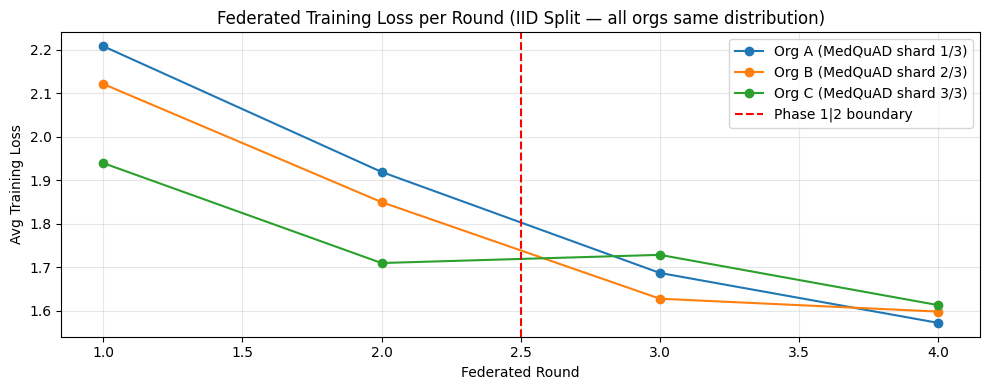

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

colors = ["tab:blue", "tab:orange", "tab:green"]
all_rounds = history["phase1"] + history["phase2"]
n_rounds = len(all_rounds)

for client_idx in range(CFG.num_clients):
    losses = [all_rounds[r][client_idx] for r in range(n_rounds)]
    ax.plot(range(1, n_rounds + 1), losses,
            marker="o", label=org_names[client_idx], color=colors[client_idx % len(colors)])

if CFG.num_rounds_phase1 < n_rounds:
    ax.axvline(x=CFG.num_rounds_phase1 + 0.5, color="red", linestyle="--",
               label="Phase 1|2 boundary")

ax.set_xlabel("Federated Round")
ax.set_ylabel("Avg Training Loss")
ax.set_title("Federated Training Loss per Round (IID Split — all orgs same distribution)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Personalization — each org fine-tunes Global v2 on its own shard

With IID data, personalized models should be very similar to the global model since all shards come from the same distribution.


In [22]:
personalized_states = {}

for client in clients:
    print(f"\nPersonalizing for {client.name}...")
    set_peft_model_state_dict(global_model, global_v2_state)
    personalized_lora, _ = client.local_train(global_model, CFG, round_tag=" personalization")
    personalized_states[client.name] = personalized_lora

    safe_name = client.name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
    pdir = os.path.join(CFG.output_dir, f"personalized_{safe_name}")
    os.makedirs(pdir, exist_ok=True)
    set_peft_model_state_dict(global_model, personalized_lora)
    global_model.save_pretrained(pdir)
    print(f"  Saved personalized adapter to {pdir}")

print("\nPersonalization complete.")



Personalizing for Org A (MedQuAD shard 1/3)...
  [Org A (MedQuAD shard 1/3) personalization] steps=60 avg_loss=1.5561
  Saved personalized adapter to ./fl_outputs/personalized_Org_A_MedQuAD_shard_1_3

Personalizing for Org B (MedQuAD shard 2/3)...
  [Org B (MedQuAD shard 2/3) personalization] steps=60 avg_loss=1.5414
  Saved personalized adapter to ./fl_outputs/personalized_Org_B_MedQuAD_shard_2_3

Personalizing for Org C (MedQuAD shard 3/3)...
  [Org C (MedQuAD shard 3/3) personalization] steps=60 avg_loss=1.5521
  Saved personalized adapter to ./fl_outputs/personalized_Org_C_MedQuAD_shard_3_3

Personalization complete.


## 12. Qualitative evaluation per org

With IID data, all three personalized models should give similar quality responses.


In [23]:
@torch.no_grad()
def generate_response(model, tokenizer, instruction, input_text=None, max_new_tokens=200):
    """Generate a response from the model given an instruction."""
    model.eval()
    prompt = build_prompt(instruction, "", input_text)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.cuda.amp.autocast():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    generated = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return generated.strip()


test_question = "What is (are) Glaucoma ?"

print("=" * 60)
print(f"Test question: {test_question}")
print("=" * 60)

for client in clients:
    print(f"\n--- {client.name} (Personalized Model) ---")
    set_peft_model_state_dict(global_model, personalized_states[client.name])
    response = generate_response(global_model, tokenizer, test_question)
    print(response[:500])


Test question: What is (are) Glaucoma ?

--- Org A (MedQuAD shard 1/3) (Personalized Model) ---


/tmp/ipykernel_4080/2418313769.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Glaucoma is a group of eye diseases that damage the optic nerve. The optic nerve is the main nerve that carries visual information from the eye to the brain. Glaucoma is the second leading cause of blindness in the United States. It is a leading cause of blindness in people over the age of 60. The most common type of glaucoma, open-angle glaucoma, is usually diagnosed in people over the age of 40. It is caused by a gradual loss of the fluid that normally drains from the eye. The fluid is produce

--- Org B (MedQuAD shard 2/3) (Personalized Model) ---
Glaucoma is a group of eye diseases that damage the optic nerve. The optic nerve is the main nerve that carries visual information from the eye to the brain. Glaucoma can cause vision loss or blindness.
    
There are many types of glaucoma. The most common type is open-angle glaucoma. In this type, the angle between the iris and the cornea (the colored part of the eye and the clear part of the eye) is wide. This allows fluid to drain from

In [24]:
print("=" * 60)
print("Validation loss comparison (lower is better)")
print("=" * 60)

set_peft_model_state_dict(global_model, global_v2_state)
print("\nGlobal Model v2:")
for client in clients:
    val_loss = client.evaluate(global_model, CFG)
    print(f"  {client.name}: val_loss={val_loss:.4f}")

print("\nPersonalized Models:")
for client in clients:
    set_peft_model_state_dict(global_model, personalized_states[client.name])
    val_loss = client.evaluate(global_model, CFG)
    print(f"  {client.name}: val_loss={val_loss:.4f}")

print("\nNote: With IID data, personalized and global validation losses should be close.")


Validation loss comparison (lower is better)

Global Model v2:
  Org A (MedQuAD shard 1/3): val_loss=1.5832
  Org B (MedQuAD shard 2/3): val_loss=1.6406
  Org C (MedQuAD shard 3/3): val_loss=1.5853

Personalized Models:
  Org A (MedQuAD shard 1/3): val_loss=1.5683
  Org B (MedQuAD shard 2/3): val_loss=1.6419
  Org C (MedQuAD shard 3/3): val_loss=1.5800

Note: With IID data, personalized and global validation losses should be close.


## Notes & Extensions

### IID vs Non-IID Federated Learning

This notebook implements the **IID** federated learning setting:
- All clients draw data from the same distribution (MedQuAD)
- Each client has a random, disjoint subset of the full dataset
- FedAvg converges smoothly and quickly in this setting
- Losses across all clients should be very similar per round

The original notebook (`federated_gemma_finetune (1).ipynb`) implements **Non-IID**:
- Each client has data from a completely different domain
- More realistic for real FL deployments
- FedAvg may converge more slowly

### Changing the number of clients

Change `CFG.num_clients` to any positive integer. The `iid_split()` function
will create that many equal shards automatically.

### Using a different dataset

Replace the `kagglehub.dataset_download(...)` call and update `preprocess_medquad()`
to match your dataset's schema. Everything else (IID split, training, FedAvg) stays the same.
